In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import sys

esmDMS_DIR = "/Users/dylanwells/popDMS/esmDMS"

sys.path.insert(0, esmDMS_DIR)
from esmdmsfunctions import (
    get_eigenvector_simulation_results,
    get_simulation_results,
    generate_selection, gaussian_selection, zero_selection,
    z_normalize, load_final_df,
)
from scipy.stats import pearsonr


In [2]:
import os

# ── Paths to analyse (name → directory containing layer0/, layer1/, … subdirs)
comb_path = esmDMS_DIR + "/data/bg_bf_comb_data"
bg_path   = esmDMS_DIR + "/data/inference_data/BG505"
bf_path   = esmDMS_DIR + "/data/inference_results"

PATHS = {
    "comb":  comb_path,
    "BG505": bg_path,
    "BF520": bf_path,
}

# ── Layers to analyze
LAYERS = range(0, 31, 6)

# ── Simulation parameters
N_GENS      = 30      # number of generations to simulate
SAVE_EVERY  = 1       # save counts every N generations
FITNESS_FN  = 'exp'   # 'plus1' or 'exp'

# ── Eigenvector / PCA parameters
VARIANCE_EXPLAINED_CUTOFF = 0.8   # keep PCs that together explain this fraction of variance
WEIGHT_BY_INITIAL_FREQ    = False  # weight covariance matrix by pre-selection counts

# ── Selection function (generate_selection, gaussian_selection, or zero_selection)
SEL_FUNC = gaussian_selection

# ── Inference flags
RUN_INFERENCE    = True
RUN_GAMMA        = False
CALC_ERROR_BARS  = False
INFER_IGNORED    = True

In [ ]:

# Full covariance matrix method seems to be the best

PATHS = {
    "comb":  comb_path,
    "BG505": bg_path,
    "BF520": bf_path,
}


all_results_fullcov = {}

for path_name, path in PATHS.items():
    print(f"\n{'='*60}")
    print(f"Dataset: {path_name}  |  get_simulation_results, method=fullcov")
    print('='*60)

    res = get_simulation_results(
        n_gens=N_GENS,
        embedding_df_path=path,
        sel_func=SEL_FUNC,
        inference=RUN_INFERENCE,
        gamma_analysis=RUN_GAMMA,
        fitness=FITNESS_FN,
        save_every=SAVE_EVERY,
        layers=LAYERS,
        calc_error_bars=True,
        infer_ignored_dims=INFER_IGNORED,
        method="fullcov",
    )
    all_results_fullcov[path_name] = res  # detailed_selection_results
print("\nDone. Datasets completed:", list(all_results_fullcov.keys()))

In [ ]:
# save the fullcov data for later analysis
output_file = "fullcov_all_results.pkl"
with open(output_file, "wb") as f:
    pickle.dump(all_results_fullcov, f)
print(f"\nFull covariance method all results saved to {output_file}")

In [3]:
# load the data
all_results_fullcov = None
output_file = "independent_all_results.pkl"
with open(output_file, "rb") as f:
    all_results_fullcov = pickle.load(f)


## Fitness Analysis: Inferred vs True

`all_results_fullcov[dataset]` is a 5-tuple from `get_simulation_results`:

| Index | Name | Description |
|---|---|---|
| 0 | `all_layer_fits` | `layer → array(n_variants)` — **true** fitness used in simulation |
| 1 | `all_selection_coefficients` | `layer → array(D,)` — true selection coefficients (raw embedding space) |
| 2 | `detailed_selection_results` | `layer → [s, s_joint, s_err, s_joint_err]` — **inferred** coefs |
| 3 | `all_gamma_analysis` | gamma sweep results |
| 4 | `all_generation_counts` | per-generation variant counts |

Inference is run directly on the raw embeddings (no PCA). Inferred fitness for variant $i$ is $\exp(\mathbf{x}_i^\top \mathbf{s})$ where $\mathbf{x}_i$ is the raw embedding and $\mathbf{s}$ is either a per-replicate or joint selection coefficient vector of the same dimension $D$.

In [4]:
# ── Helper functions for fitness analysis

FITNESS_FN = 'exp'  # must match the fitness function used in get_simulation_results
NCOLS = 6           # layers per row within grid figures


def get_embeddings(dataset_name, layer):
    """Load raw embeddings for a given dataset and layer."""
    df = load_final_df(layer, PATHS[dataset_name])
    return np.vstack(df['Embedding'].tolist())  # (N, D)


def inferred_fitness(embeddings, sel_coefs, fitness_fn='exp'):
    """Fitness of each variant given raw embeddings and selection coefficients.
    
    embeddings : (N, D)
    sel_coefs  : (D,)
    returns    : (N,)
    """
    dot = embeddings @ sel_coefs
    if fitness_fn == 'exp':
        return np.exp(dot)
    elif fitness_fn == 'plus1':
        return np.maximum(1.0 + dot, 0.0)
    else:
        raise ValueError(f"Unknown fitness function: {fitness_fn}")


def _scatter_panel(ax, true_z, inf_z, title, color='steelblue'):
    """Scatter plot with diagonal reference line and Pearson r annotation."""
    r, _ = pearsonr(true_z, inf_z)
    ax.scatter(true_z, inf_z, alpha=0.4, s=8, color=color, rasterized=True)
    lo = min(true_z.min(), inf_z.min()) - 0.3
    hi = max(true_z.max(), inf_z.max()) + 0.3
    ax.plot([lo, hi], [lo, hi], 'r--', linewidth=0.8)
    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
    ax.set_title(title, fontsize=9)
    ax.set_xlabel('True fitness (z)', fontsize=7)
    ax.set_ylabel('Inferred fitness (z)', fontsize=7)
    ax.tick_params(labelsize=7)
    ax.annotate(f'r = {r:.3f}', xy=(0.05, 0.93), xycoords='axes fraction',
                ha='left', va='top', fontsize=8,
                bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.85))
    return r

### Per-replicate inferred fitness vs true fitness

One figure per dataset per replicate. Each figure shows all available layers tiled in a 6-column grid. Inferred fitness uses the per-replicate selection coefficients $\mathbf{s}_r$ dotted with the raw embeddings.

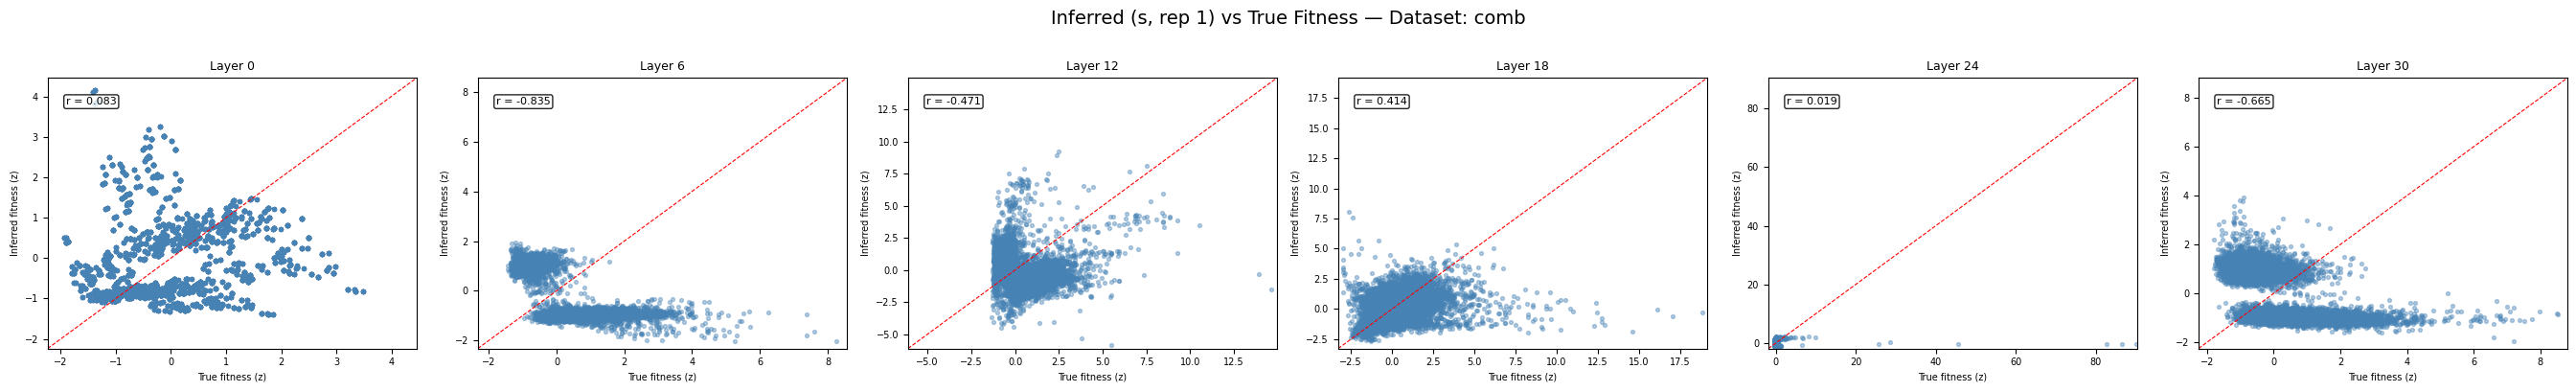

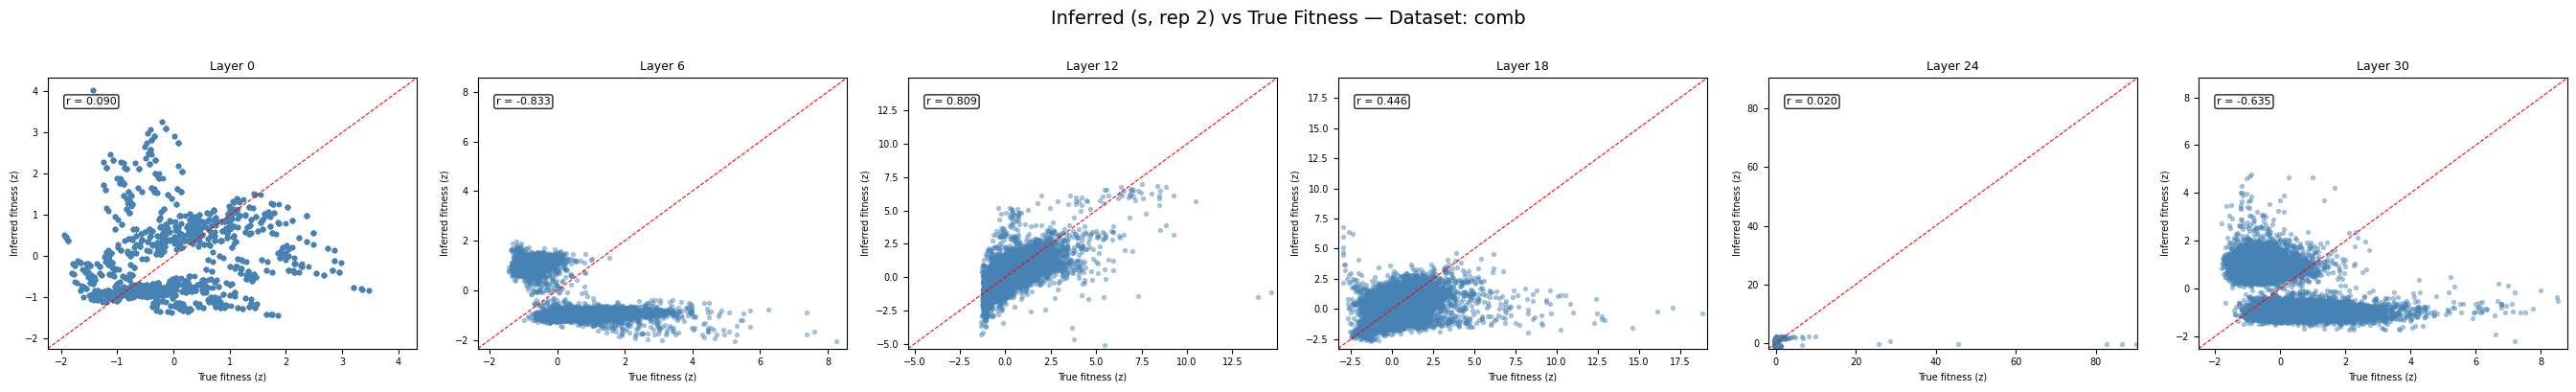

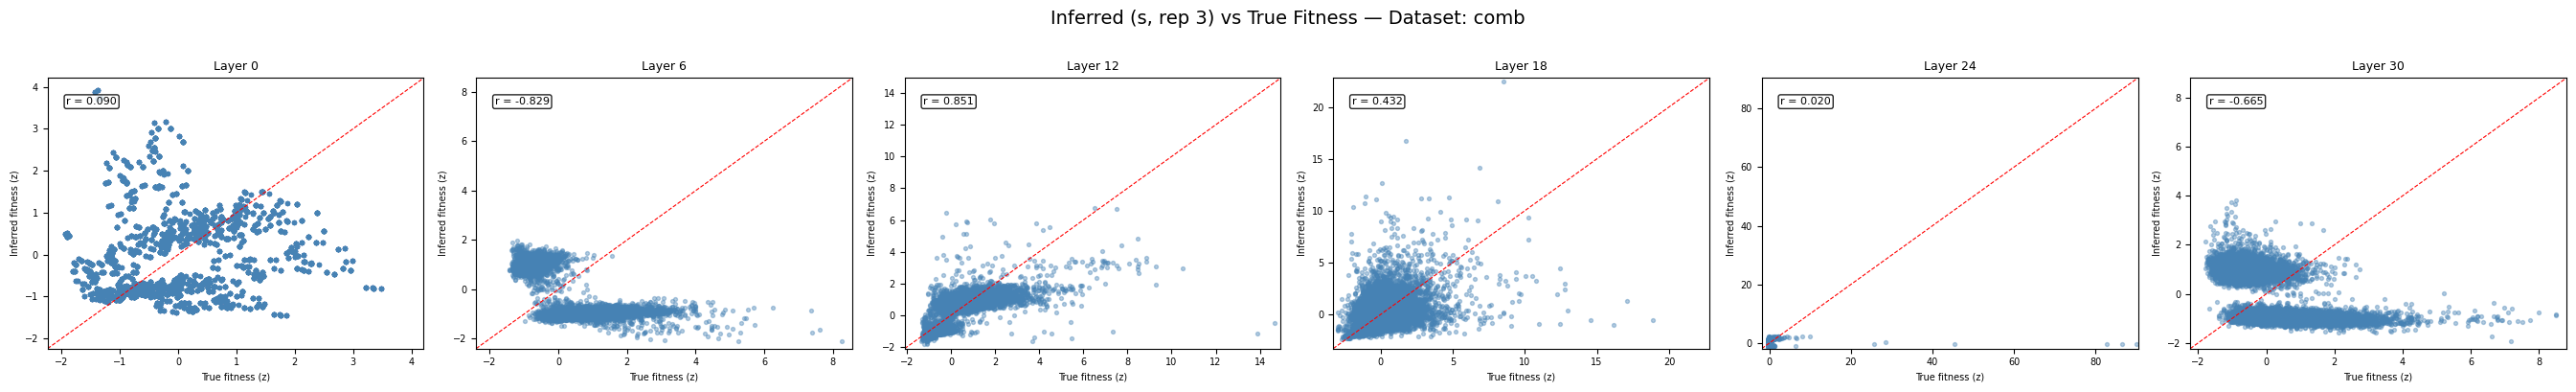

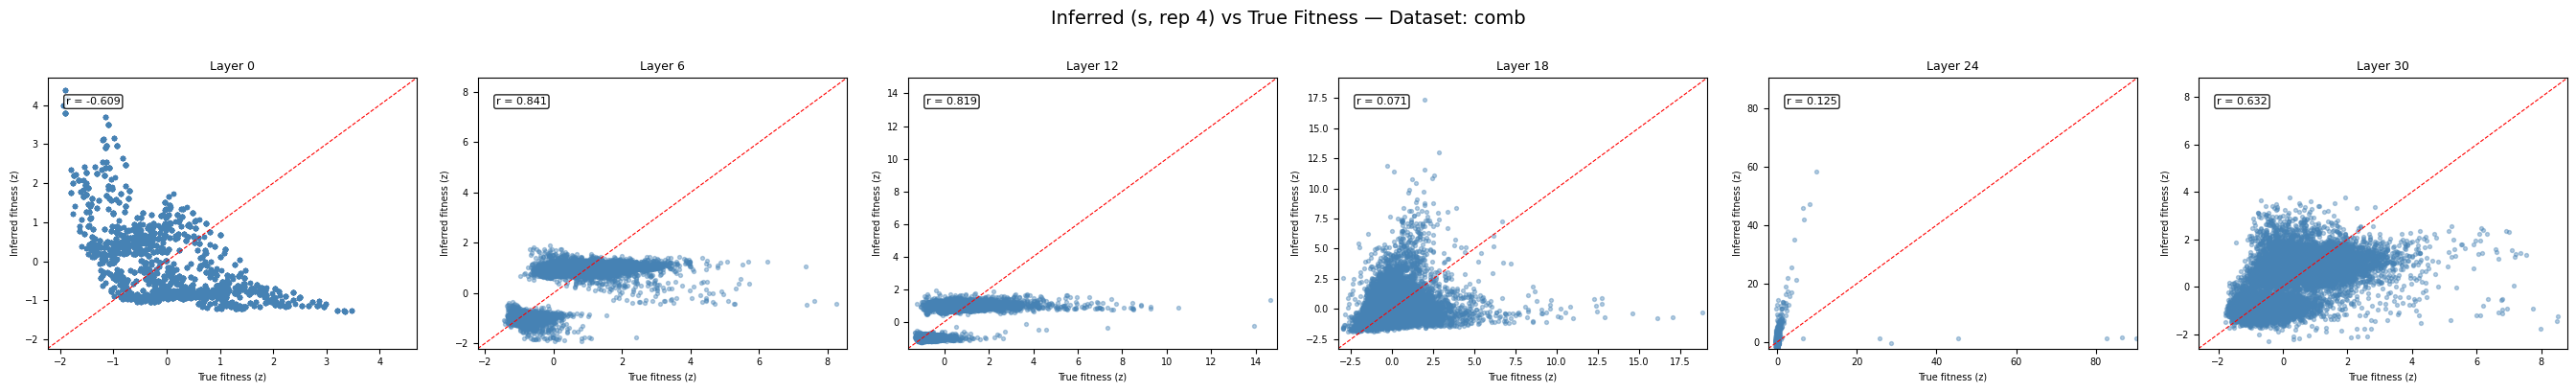

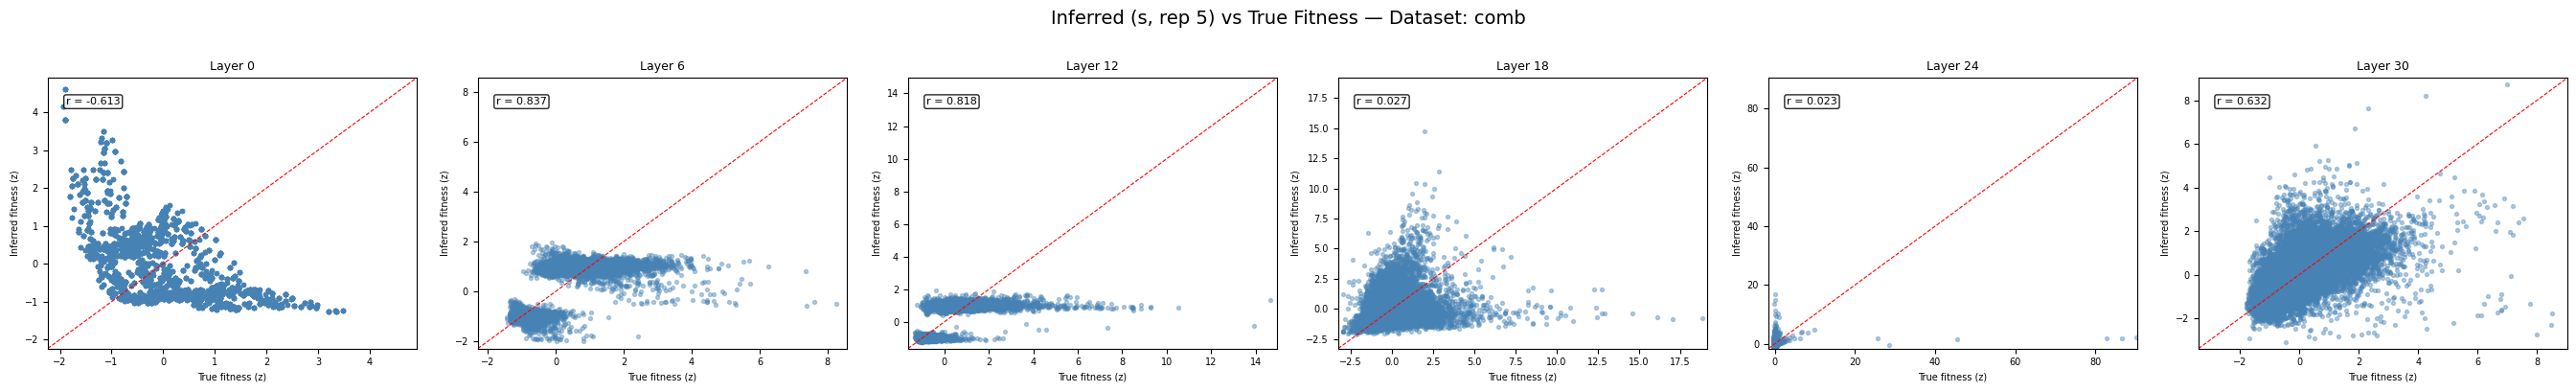

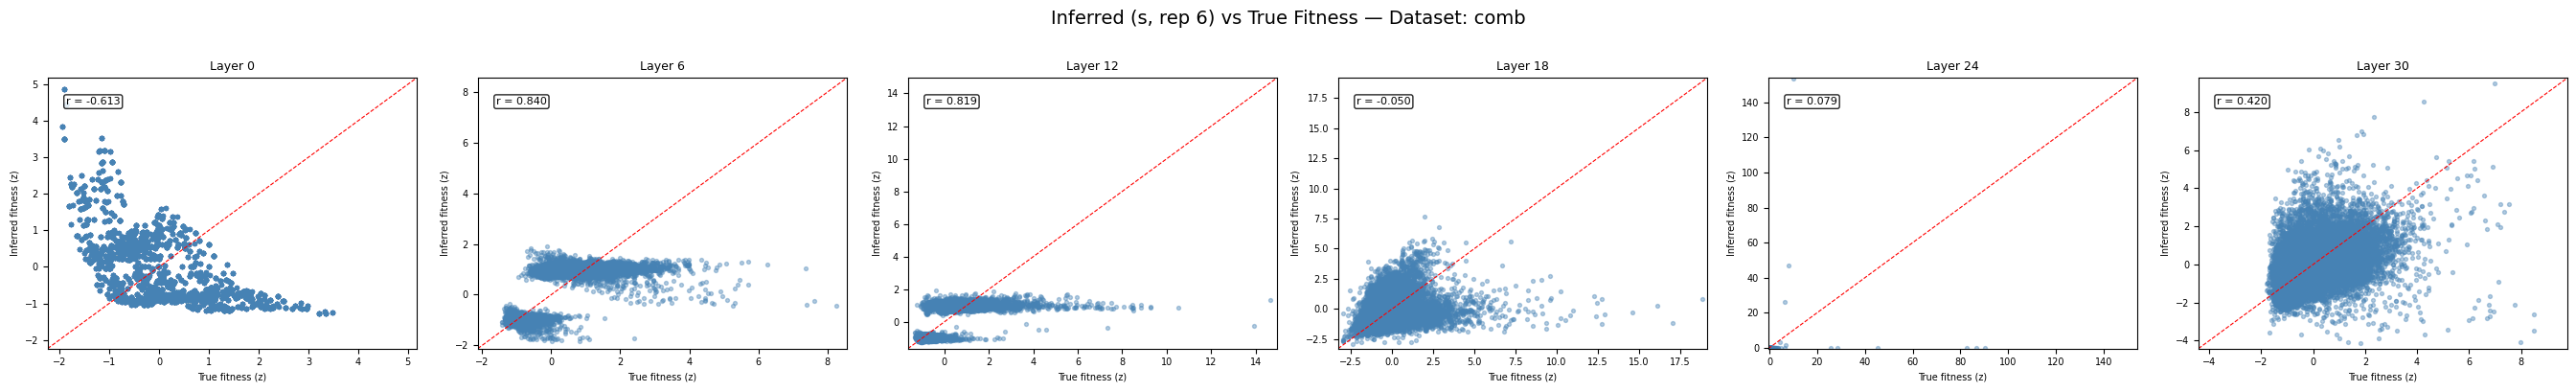

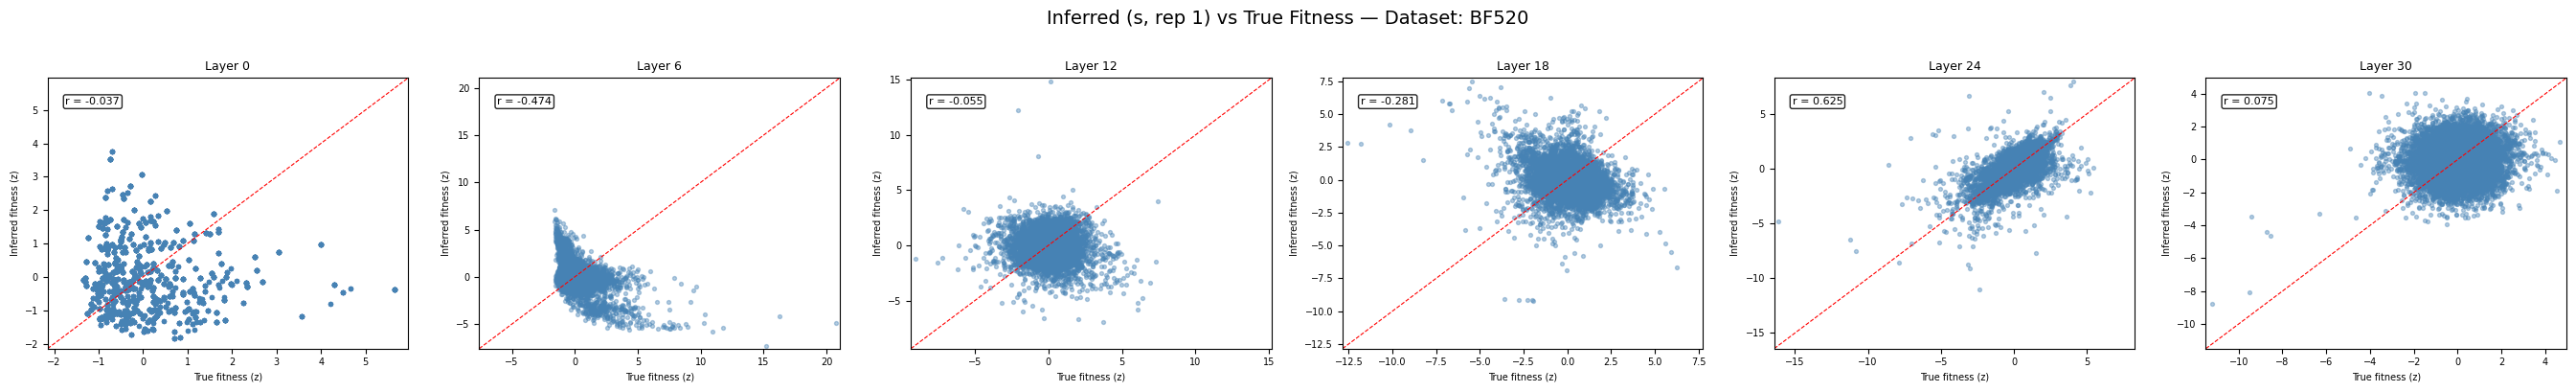

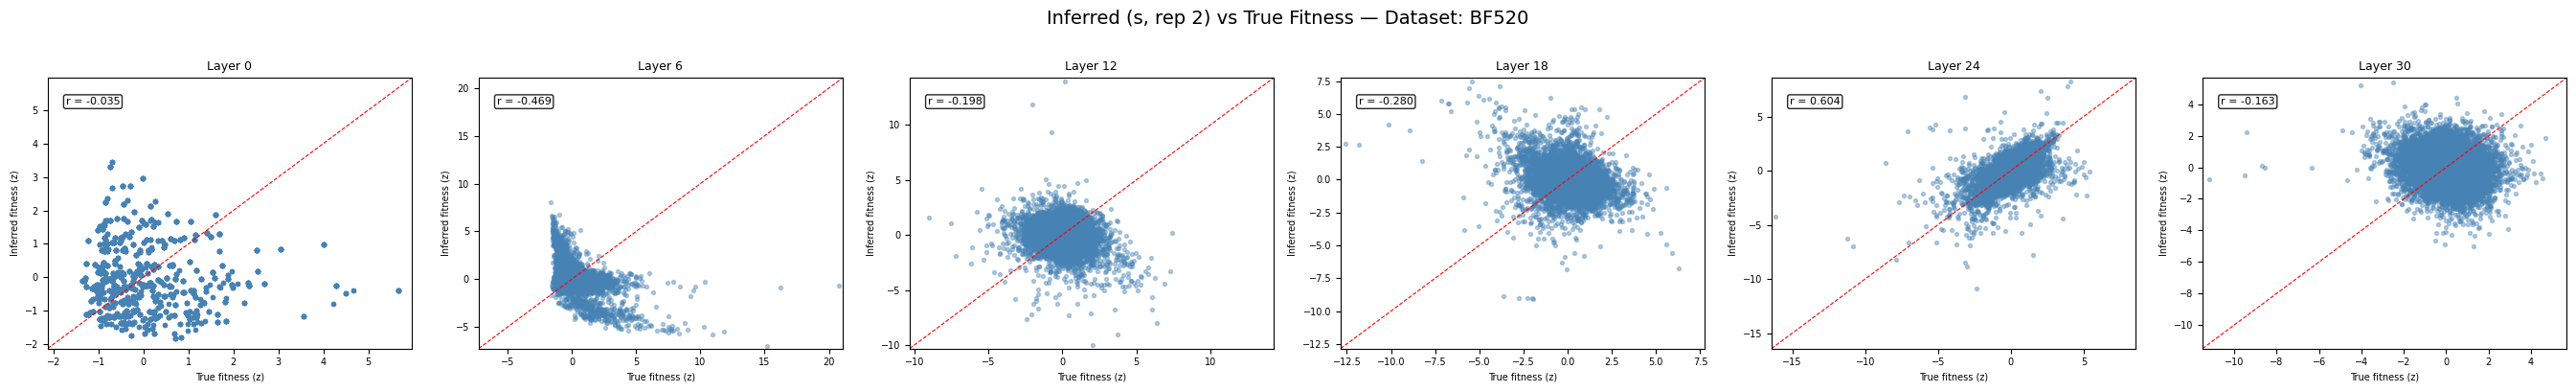

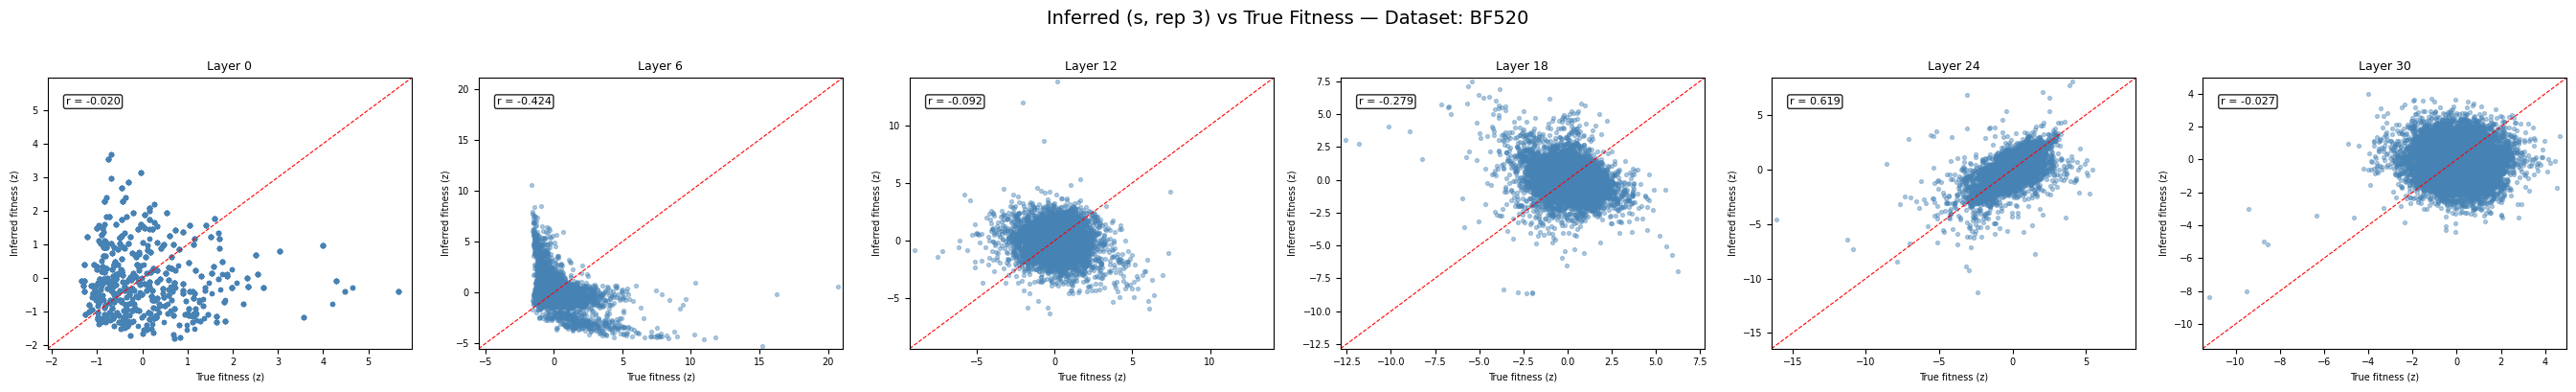

In [5]:
# ── Per-layer, per-rep scatter plots
# One figure per (dataset, replicate); all layers tiled in a NCOLS-column grid.

for dataset in all_results_fullcov:
    sim_data         = all_results_fullcov[dataset]
    all_layer_fits   = sim_data[0]  # layer -> array(n_variants) true fitness
    detailed_results = sim_data[2]  # layer -> [s, s_joint, s_err, s_joint_err]

    layers_available = sorted(detailed_results.keys())
    n_layers = len(layers_available)
    n_reps   = detailed_results[layers_available[0]][0].shape[0]  # s shape: (n_reps, D)
    nrows    = (n_layers + NCOLS - 1) // NCOLS

    for rep in range(n_reps):
        fig, axes = plt.subplots(nrows, NCOLS,
                                  figsize=(4.5 * NCOLS, 4 * nrows),
                                  squeeze=False)
        fig.suptitle(
            f'Inferred (s, rep {rep + 1}) vs True Fitness — Dataset: {dataset}',
            fontsize=14, y=1.01
        )

        for idx, layer in enumerate(layers_available):
            row, col = divmod(idx, NCOLS)
            ax = axes[row, col]

            true_z = z_normalize(np.array(all_layer_fits[layer]))
            s      = detailed_results[layer][0]          # (n_reps, D)
            emb    = get_embeddings(dataset, layer)      # (N, D)
            inf_z  = z_normalize(inferred_fitness(emb, s[rep], FITNESS_FN))

            _scatter_panel(ax, true_z, inf_z, title=f'Layer {layer}')

        for idx in range(n_layers, nrows * NCOLS):
            row, col = divmod(idx, NCOLS)
            axes[row, col].set_visible(False)

        plt.tight_layout()
        plt.savefig(f'fitness_scatter_rep{rep + 1}_{dataset}.png', dpi=80, bbox_inches='tight')
        plt.show()

### $s_\text{joint}$ inferred fitness vs true fitness

Same grid layout per dataset, but using the joint selection coefficients $\mathbf{s}_\text{joint}$ inferred across all replicates simultaneously.

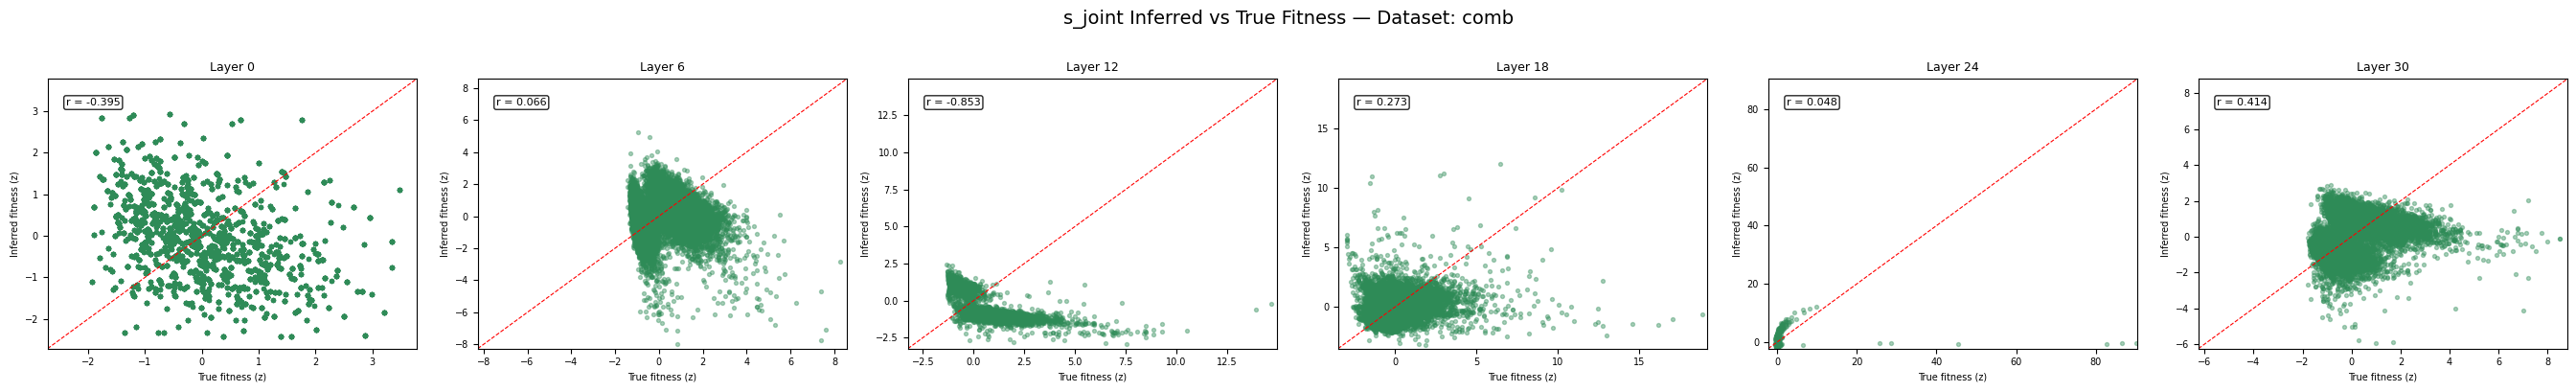

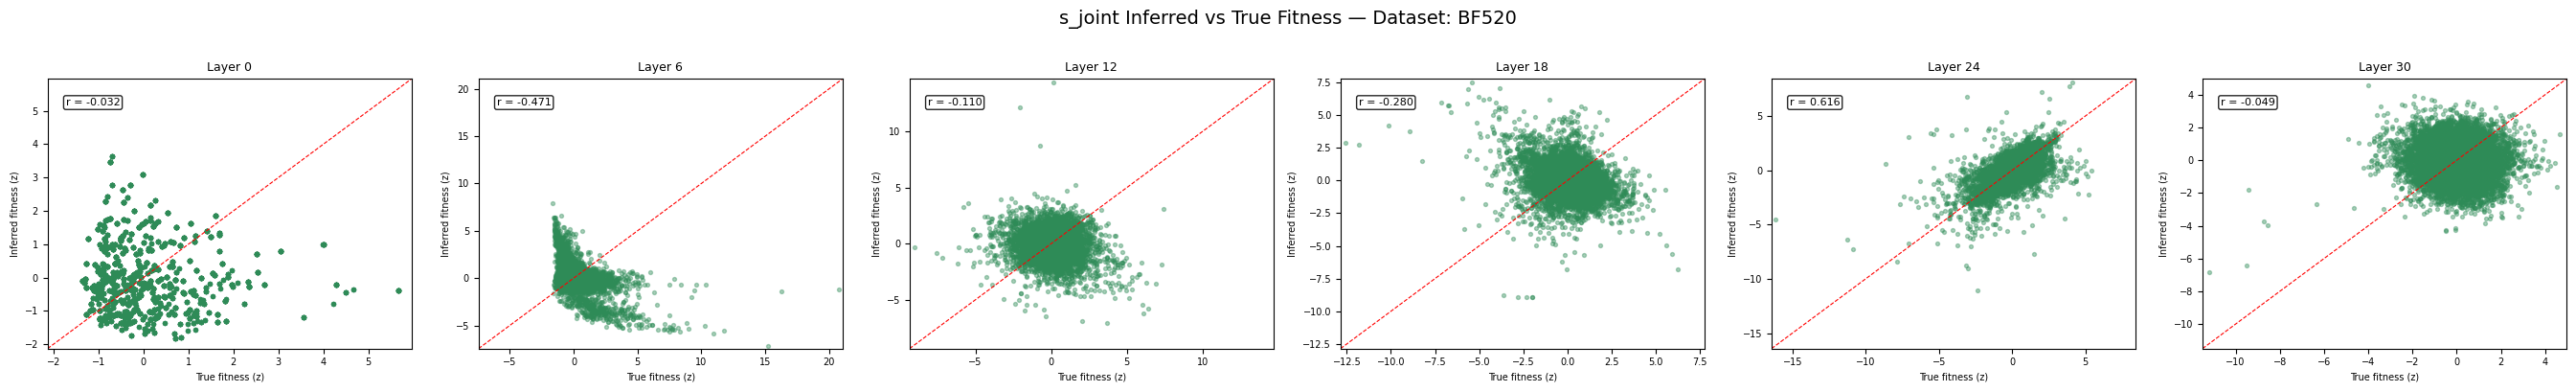

In [6]:
# ── Per-layer s_joint inferred fitness vs true fitness
# One figure per dataset; all layers tiled in a NCOLS-column grid.

for dataset in all_results_fullcov:
    sim_data         = all_results_fullcov[dataset]
    all_layer_fits   = sim_data[0]
    detailed_results = sim_data[2]

    layers_available = sorted(detailed_results.keys())
    n_layers = len(layers_available)
    nrows    = (n_layers + NCOLS - 1) // NCOLS

    fig, axes = plt.subplots(nrows, NCOLS,
                              figsize=(4.5 * NCOLS, 4 * nrows),
                              squeeze=False)
    fig.suptitle(
        f's_joint Inferred vs True Fitness — Dataset: {dataset}',
        fontsize=14, y=1.01
    )

    for idx, layer in enumerate(layers_available):
        row, col = divmod(idx, NCOLS)
        ax = axes[row, col]

        true_z  = z_normalize(np.array(all_layer_fits[layer]))
        s_joint = detailed_results[layer][1]             # (D,)
        emb     = get_embeddings(dataset, layer)         # (N, D)
        inf_z   = z_normalize(inferred_fitness(emb, s_joint, FITNESS_FN))

        _scatter_panel(ax, true_z, inf_z, title=f'Layer {layer}', color='seagreen')

    for idx in range(n_layers, nrows * NCOLS):
        row, col = divmod(idx, NCOLS)
        axes[row, col].set_visible(False)

    plt.tight_layout()
    plt.savefig(f'fitness_scatter_sjoint_{dataset}.png', dpi=80, bbox_inches='tight')
    plt.show()

### Pearson $r$ across ESM-2 layers

Summary plot: Pearson $r$ between inferred and true fitness as a function of ESM-2 layer, for each dataset. Bold green line = $s_\text{joint}$; dashed blue lines = per-replicate $s_r$.

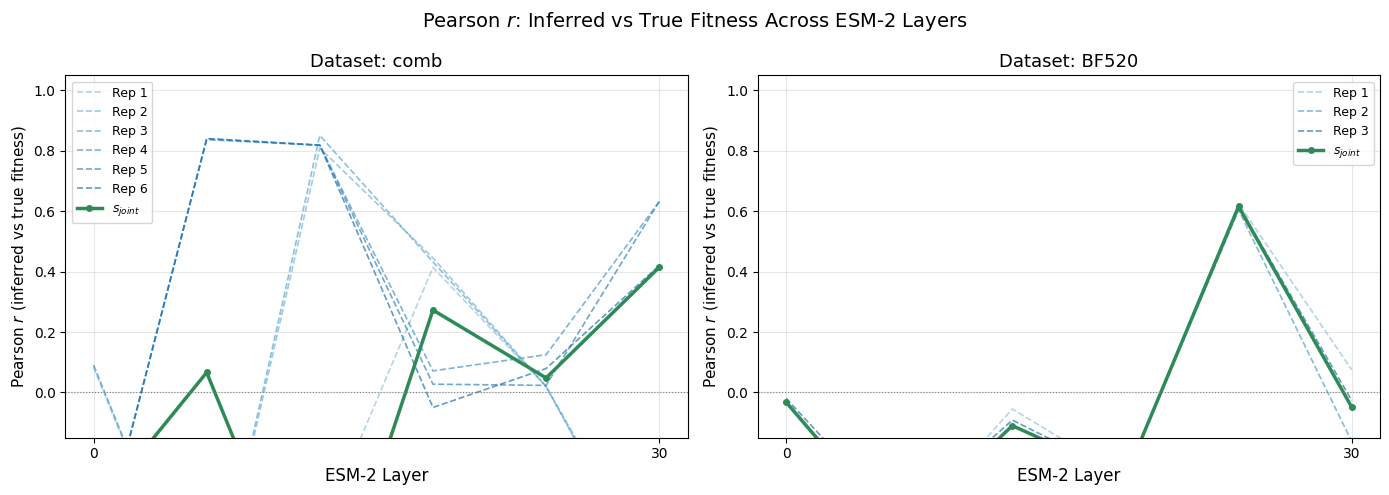

In [7]:
# ── Summary: Pearson r across all layers for each dataset
# Bold green = s_joint; dashed blue lines = per-replicate s.

datasets = list(all_results_fullcov.keys())
fig, axes = plt.subplots(1, len(datasets), figsize=(7 * len(datasets), 5), squeeze=False)

for ax, dataset in zip(axes.flatten(), datasets):
    sim_data         = all_results_fullcov[dataset]
    all_layer_fits   = sim_data[0]
    detailed_results = sim_data[2]

    layers_available = sorted(detailed_results.keys())
    n_reps = detailed_results[layers_available[0]][0].shape[0]

    rs_joint   = []
    rs_per_rep = [[] for _ in range(n_reps)]

    for layer in layers_available:
        true_z = z_normalize(np.array(all_layer_fits[layer]))
        emb    = get_embeddings(dataset, layer)          # (N, D)

        s_joint = detailed_results[layer][1]             # (D,)
        inf_z   = z_normalize(inferred_fitness(emb, s_joint, FITNESS_FN))
        rs_joint.append(pearsonr(true_z, inf_z)[0])

        s = detailed_results[layer][0]                   # (n_reps, D)
        for rep in range(n_reps):
            inf_z_rep = z_normalize(inferred_fitness(emb, s[rep], FITNESS_FN))
            rs_per_rep[rep].append(pearsonr(true_z, inf_z_rep)[0])

    rep_colors = plt.cm.Blues(np.linspace(0.4, 0.75, n_reps))
    for rep in range(n_reps):
        ax.plot(layers_available, rs_per_rep[rep],
                color=rep_colors[rep], linewidth=1.2, alpha=0.7,
                linestyle='--', label=f'Rep {rep + 1}')

    ax.plot(layers_available, rs_joint,
            color='seagreen', linewidth=2.5, marker='o', markersize=4,
            label='$s_{joint}$')

    ax.set_xlabel('ESM-2 Layer', fontsize=12)
    ax.set_ylabel('Pearson $r$ (inferred vs true fitness)', fontsize=11)
    ax.set_title(f'Dataset: {dataset}', fontsize=13)
    ax.set_ylim(-0.15, 1.05)
    ax.axhline(0, color='gray', linestyle=':', linewidth=0.8)
    ax.set_xticks(layers_available[::5])
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)

fig.suptitle('Pearson $r$: Inferred vs True Fitness Across ESM-2 Layers', fontsize=14)
plt.tight_layout()
plt.savefig('pearson_r_across_layers.png', dpi=100, bbox_inches='tight')
plt.show()

---

## Selection Coefficient Analysis: Inferred vs True

Direct comparison of the inferred selection coefficients $\mathbf{s}$ against the true coefficients used to generate the simulated data. Each point is one embedding dimension. Per-replicate $\mathbf{s}_r$ are shown as different colors on the same axes; $\mathbf{s}_\text{joint}$ is shown in black.

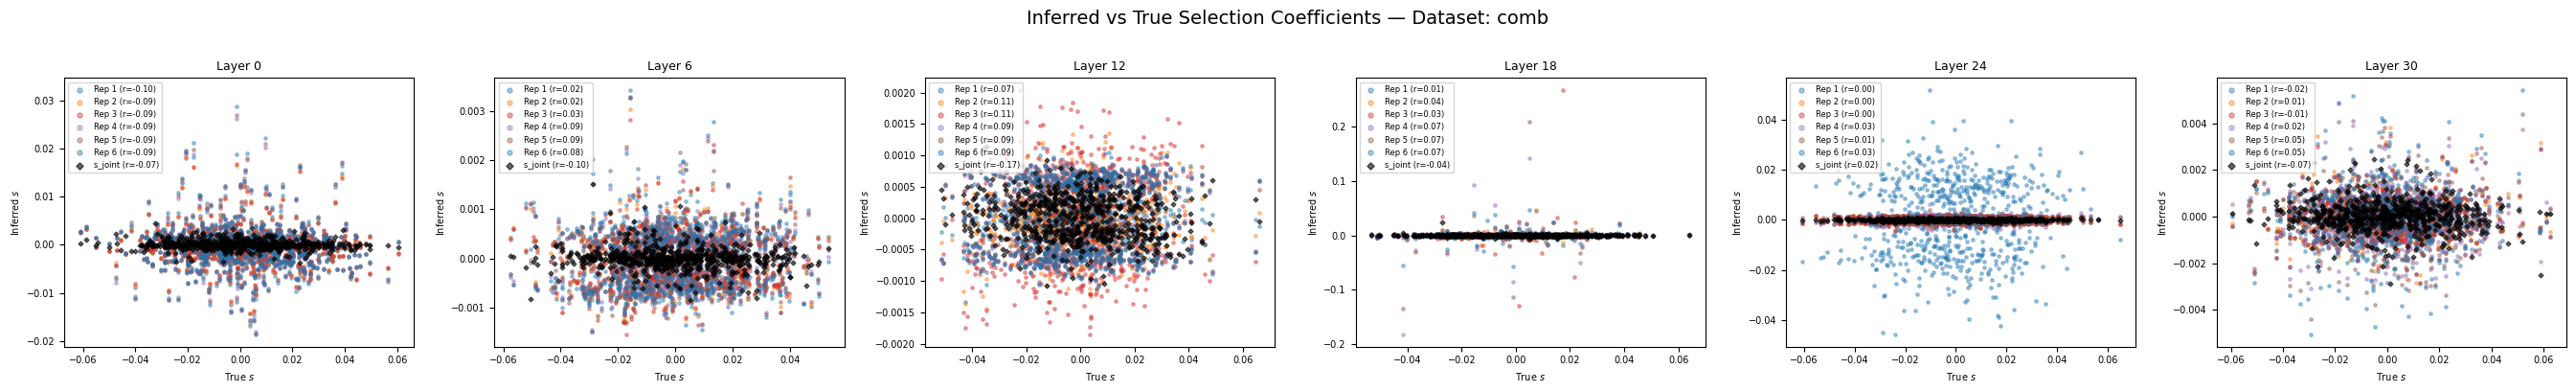

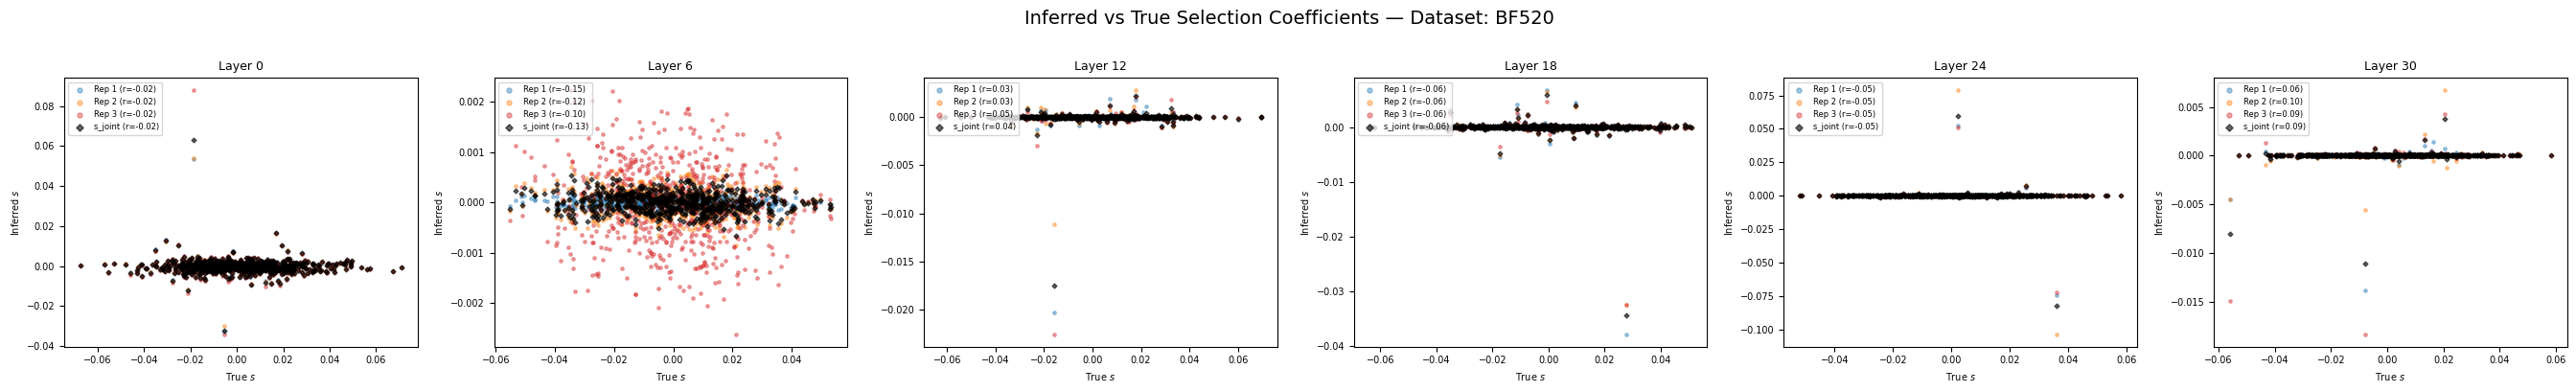

In [8]:
# ── Per-layer selection coefficient scatter plots
# One figure per dataset; layers tiled in NCOLS-column grid.
# All replicates overlaid on each panel in different colors; s_joint in black.

REP_COLORS = ['tab:blue', 'tab:orange', 'tab:red', 'tab:purple', 'tab:brown']

for dataset in all_results_fullcov:
    sim_data         = all_results_fullcov[dataset]
    true_sel_coefs   = sim_data[1]  # layer -> array(D,) true selection coefficients
    detailed_results = sim_data[2]  # layer -> [s, s_joint, s_err, s_joint_err]

    layers_available = sorted(detailed_results.keys())
    n_layers = len(layers_available)
    n_reps   = detailed_results[layers_available[0]][0].shape[0]
    nrows    = (n_layers + NCOLS - 1) // NCOLS

    fig, axes = plt.subplots(nrows, NCOLS,
                              figsize=(4.5 * NCOLS, 4 * nrows),
                              squeeze=False)
    fig.suptitle(
        f'Inferred vs True Selection Coefficients — Dataset: {dataset}',
        fontsize=14, y=1.01
    )

    for idx, layer in enumerate(layers_available):
        row, col = divmod(idx, NCOLS)
        ax = axes[row, col]

        s_true  = true_sel_coefs[layer]          # (D,)
        s       = detailed_results[layer][0]     # (n_reps, D)
        s_joint = detailed_results[layer][1]     # (D,)

        for rep in range(n_reps):
            r, _ = pearsonr(s_true, s[rep])
            ax.scatter(s_true, s[rep],
                       color=REP_COLORS[rep % len(REP_COLORS)],
                       alpha=0.4, s=6, rasterized=True,
                       label=f'Rep {rep + 1} (r={r:.2f})')

        r_joint, _ = pearsonr(s_true, s_joint)
        ax.scatter(s_true, s_joint,
                   color='black', alpha=0.6, s=6, marker='D', rasterized=True,
                   label=f's_joint (r={r_joint:.2f})')

        ax.set_title(f'Layer {layer}', fontsize=9)
        ax.set_xlabel('True $s$', fontsize=7)
        ax.set_ylabel('Inferred $s$', fontsize=7)
        ax.tick_params(labelsize=7)
        ax.legend(fontsize=6, markerscale=1.5, loc='upper left')

    for idx in range(n_layers, nrows * NCOLS):
        row, col = divmod(idx, NCOLS)
        axes[row, col].set_visible(False)

    plt.tight_layout()
    plt.savefig(f'sel_coef_scatter_{dataset}.png', dpi=80, bbox_inches='tight')
    plt.show()

### Pearson $r$ of selection coefficients across ESM-2 layers

Pearson $r$ between inferred and true selection coefficients as a function of ESM-2 layer. Bold line = $s_\text{joint}$; dashed lines = per-replicate $s_r$.

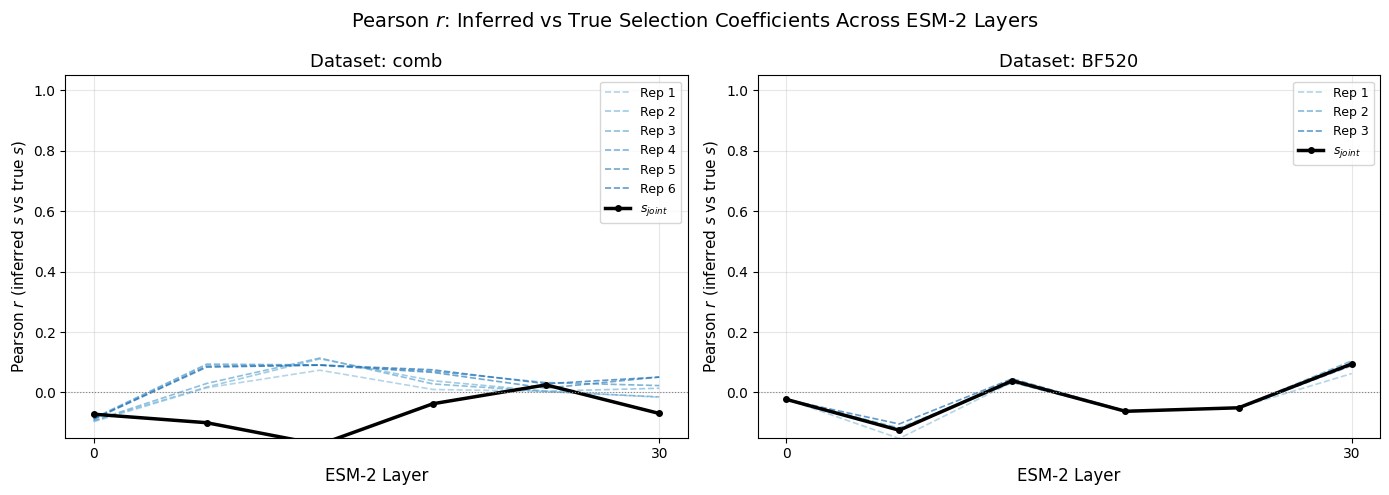

In [9]:
# ── Summary: Pearson r of s_joint and per-rep s vs s_true across layers

datasets = list(all_results_fullcov.keys())
fig, axes = plt.subplots(1, len(datasets), figsize=(7 * len(datasets), 5), squeeze=False)

for ax, dataset in zip(axes.flatten(), datasets):
    sim_data         = all_results_fullcov[dataset]
    true_sel_coefs   = sim_data[1]
    detailed_results = sim_data[2]

    layers_available = sorted(detailed_results.keys())
    n_reps = detailed_results[layers_available[0]][0].shape[0]

    rs_joint   = []
    rs_per_rep = [[] for _ in range(n_reps)]

    for layer in layers_available:
        s_true  = true_sel_coefs[layer]
        s       = detailed_results[layer][0]   # (n_reps, D)
        s_joint = detailed_results[layer][1]   # (D,)

        rs_joint.append(pearsonr(s_true, s_joint)[0])
        for rep in range(n_reps):
            rs_per_rep[rep].append(pearsonr(s_true, s[rep])[0])

    rep_colors = plt.cm.Blues(np.linspace(0.4, 0.75, n_reps))
    for rep in range(n_reps):
        ax.plot(layers_available, rs_per_rep[rep],
                color=rep_colors[rep], linewidth=1.2, alpha=0.7,
                linestyle='--', label=f'Rep {rep + 1}')

    ax.plot(layers_available, rs_joint,
            color='black', linewidth=2.5, marker='o', markersize=4,
            label='$s_{joint}$')

    ax.set_xlabel('ESM-2 Layer', fontsize=12)
    ax.set_ylabel('Pearson $r$ (inferred $s$ vs true $s$)', fontsize=11)
    ax.set_title(f'Dataset: {dataset}', fontsize=13)
    ax.set_ylim(-0.15, 1.05)
    ax.axhline(0, color='gray', linestyle=':', linewidth=0.8)
    ax.set_xticks(layers_available[::5])
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)

fig.suptitle('Pearson $r$: Inferred vs True Selection Coefficients Across ESM-2 Layers', fontsize=14)
plt.tight_layout()
plt.savefig('pearson_r_sel_coef_across_layers.png', dpi=100, bbox_inches='tight')
plt.show()